# **Module** **3** **Assignment**: **Cleaning** ***“Messy”*** **Data** **-** **Wine Dataset**

# **Assignment**:
## Cleaning ‘Messy’ Data – Wine Dataset

**Author:** Nicolette Mtisi

The notebook is organized in a clear structure, beginning with an introduction, followed by exploratory data analysis (EDA), data preparation, a review of the cleaned dataset, and final conclusions. Visualizations are properly labeled, and code cells include comments to enhance readability and interpretation.

#**1. Introduction**

The purpose of this assignment is to clean and prepare a dataset of over 12,700 wine records that contains both data integrity and usability issues. The dataset includes variables describing chemical composition (e.g., acidity, pH, alcohol content), label appeal, expert ratings (STARS), and a response variable (TARGET), which represents the number of wine cases sold.  

The workflow of this notebook follows a structured sequence designed to ensure the dataset is suitable for downstream machine learning tasks:  

1. **Load and Inspect the Dataset**  
   - Import the dataset and examine its structure, data types, and overall shape.  

2. **Exploratory Data Analysis (EDA)**  
   - Perform descriptive statistical analysis.  
   - Visualize univariate distributions using histograms, bar plots, and boxplots.  
   - Identify missing values, invalid values (e.g., negative chemical concentrations), and outliers.  
   - Assess skewness and distributional characteristics.  
   - Examine relationships between variables through correlation heatmaps and pairplots.  

3. **Summarize EDA Findings**  
   - Document all data integrity issues.  
   - Highlight distributional issues (e.g., skewness) and determine which variables may require transformation.  
   - Provide justification for the selected cleaning and preparation strategies.  

4. **Data Preparation**  
   - Replace or impute missing values (median for numeric variables, mode for categorical/ordinal variables).  
   - Address invalid values (e.g., convert negative values to `NaN` and impute).  
   - Apply transformations (e.g., log transformation of skewed variables such as AcidIndex).  
   - Create new features if needed (e.g., transformed versions of skewed variables).  

5. **Prepped Data Review**  
   - Re-run descriptive statistics and visualizations on the cleaned dataset.  
   - Compare “before” vs “after” distributions to validate improvements.  
   - Confirm that no missing values remain and that skewness/outlier issues have been reduced.  

6. **Conclusions**  
   - Summarize the overall improvements achieved through cleaning and transformation.  
   - Discuss how the prepared dataset is now better suited for machine learning model training.  


# **2. Exploratory Data Analysis**

## **2.1 Data Overview**

We begin by loading the dataset, assigning column names, and performing initial inspection to confirm structure and dimensionality.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset from the raw GitHub link
url = "https://raw.githubusercontent.com/nic-stack/DAV6150-/main/M3_Data.csv"
df = pd.read_csv(url, header=None)

print(df.shape)
df.head()


(12796, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
1,1,3,3.2,1.16,-0.98,54.2,-0.567,NaN,268,0.9928,3.33,-0.59,9.9,0,8,2
2,2,3,4.5,0.16,-0.81,26.1,-0.425,15,-327,1.02792,3.38,0.7,NaN,-1,7,3
3,4,5,7.1,2.64,-0.88,14.8,0.037,214,142,0.99518,3.12,0.48,22,-1,8,3
4,5,3,5.7,0.385,0.04,18.8,-0.425,22,115,0.9964,2.24,1.83,6.2,-1,6,1


In [2]:
# sanity check - make sure data was read in as expected
df.head(9)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
1,1,3,3.2,1.16,-0.98,54.2,-0.567,NaN,268,0.9928,3.33,-0.59,9.9,0,8,2
2,2,3,4.5,0.16,-0.81,26.1,-0.425,15,-327,1.02792,3.38,0.7,NaN,-1,7,3
3,4,5,7.1,2.64,-0.88,14.8,0.037,214,142,0.99518,3.12,0.48,22,-1,8,3
4,5,3,5.7,0.385,0.04,18.8,-0.425,22,115,0.9964,2.24,1.83,6.2,-1,6,1
5,6,4,8,0.33,-1.26,9.4,NaN,-167,108,0.99457,3.12,1.77,13.7,0,9,2
6,7,0,11.3,0.32,0.59,2.2,0.556,-37,15,0.9994,3.2,1.29,15.4,0,11,NaN
7,8,0,7.7,0.29,-0.4,21.5,0.06,287,156,0.99572,3.49,1.21,10.3,0,8,NaN
8,11,4,6.5,-1.22,0.34,1.4,0.04,523,551,1.03236,3.2,NaN,11.6,1,7,3


In [3]:
df.columns = [
    "INDEX", "TARGET", "FixedAcidity", "VolatileAcidity", "CitricAcid",
    "ResidualSugar", "Chlorides", "FreeSulfurDioxide", "TotalSulfurDioxide",
    "Density", "pH", "Sulphates", "Alcohol", "LabelAppeal", "AcidIndex", "STARS"
]


# Drop the first row
df = df.drop(index=0).reset_index(drop=True)

# Dropping INDEX as it is a unique identifier.
df.drop(columns=["INDEX"], inplace=True)


# Sanity check
print(df.shape)
df.head()

(12795, 15)


,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,3,3.2,1.16,-0.98,54.2,-0.567,NaN,268,0.9928,3.33,-0.59,9.9,0,8,2
1,3,4.5,0.16,-0.81,26.1,-0.425,15,-327,1.02792,3.38,0.7,NaN,-1,7,3
2,5,7.1,2.64,-0.88,14.8,0.037,214,142,0.99518,3.12,0.48,22,-1,8,3
3,3,5.7,0.385,0.04,18.8,-0.425,22,115,0.9964,2.24,1.83,6.2,-1,6,1
4,4,8,0.33,-1.26,9.4,NaN,-167,108,0.99457,3.12,1.77,13.7,0,9,2


**Findings**: The dataset has 12,795 rows and 16 columns.

## **2.2 Descriptive Statistics**

We compute summary statistics, including quartiles, standard deviation, skewness, and missingness.

In [4]:
import pandas as pd
import numpy as np

# Ensure numeric conversion where possible (invalid strings -> NaN)
df_numeric = df.apply(pd.to_numeric, errors="ignore")

# Describe only numeric columns
stats = df_numeric.describe(percentiles=[.25, .5, .75]).T

# Add median, IQR, missingness, skewness
stats["median"] = df_numeric.median(numeric_only=True)
stats["IQR"] = stats["75%"] - stats["25%"]
stats["missing_count"] = df_numeric.isnull().sum()
stats["missing_%"] = round(df_numeric.isnull().mean() * 100, 2)
stats["skewness"] = df_numeric.skew(numeric_only=True)

# Reorder for readability
stats = stats[["count","missing_count","missing_%","mean","median","std","min","25%","50%","75%","max","IQR","skewness"]]

stats


/tmp/ipython-input-2169764809.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_numeric = df.apply(pd.to_numeric, errors="ignore")


,count,missing_count,missing_%,mean,median,std,min,25%,50%,75%,max,IQR,skewness
TARGET,12795.0,0,0.00,3.029074,3.00000,1.926368,0.00000,2.00000,3.00000,4.000000,8.00000,2.000000,-0.326378
FixedAcidity,12795.0,0,0.00,7.075717,6.90000,6.317643,-18.10000,5.20000,6.90000,9.500000,34.40000,4.300000,-0.022591
VolatileAcidity,12795.0,0,0.00,0.324104,0.28000,0.784014,-2.79000,0.13000,0.28000,0.640000,3.68000,0.510000,0.020385
CitricAcid,12795.0,0,0.00,0.308413,0.31000,0.862080,-3.24000,0.03000,0.31000,0.580000,3.86000,0.550000,-0.050319
ResidualSugar,12179.0,616,4.81,5.418733,3.90000,33.749379,-127.80000,-2.00000,3.90000,15.900000,141.15000,17.900000,-0.053136
Chlorides,12157.0,638,4.99,0.054822,0.04600,0.318467,-1.17100,-0.03100,0.04600,0.153000,1.35100,0.184000,0.030435
FreeSulfurDioxide,12148.0,647,5.06,30.845571,30.00000,148.714558,-555.00000,0.00000,30.00000,70.000000,623.00000,70.000000,0.006395
TotalSulfurDioxide,12113.0,682,5.33,120.714233,123.00000,231.913211,-823.00000,27.00000,123.00000,208.000000,1057.00000,181.000000,-0.007181
Density,12795.0,0,0.00,0.994203,0.99449,0.026538,0.88809,0.98772,0.99449,1.000515,1.09924,0.012795,-0.018698
pH,12400.0,395,3.09,3.207628,3.20000,0.679687,0.48000,2.96000,3.20000,3.470000,6.13000,0.510000,0.044299


**Findings:**

Most variables are symmetric with mean ≈ median, but ResidualSugar, SulfurDioxide, and AcidIndex show high variability and extreme values. STARS has the highest missing data (\~26%), making it a critical variable to handle.


## **2.3 Univariate Analysis**



### **2.3.1 Histograms**

Histograms show the frequency distribution of numeric variables.

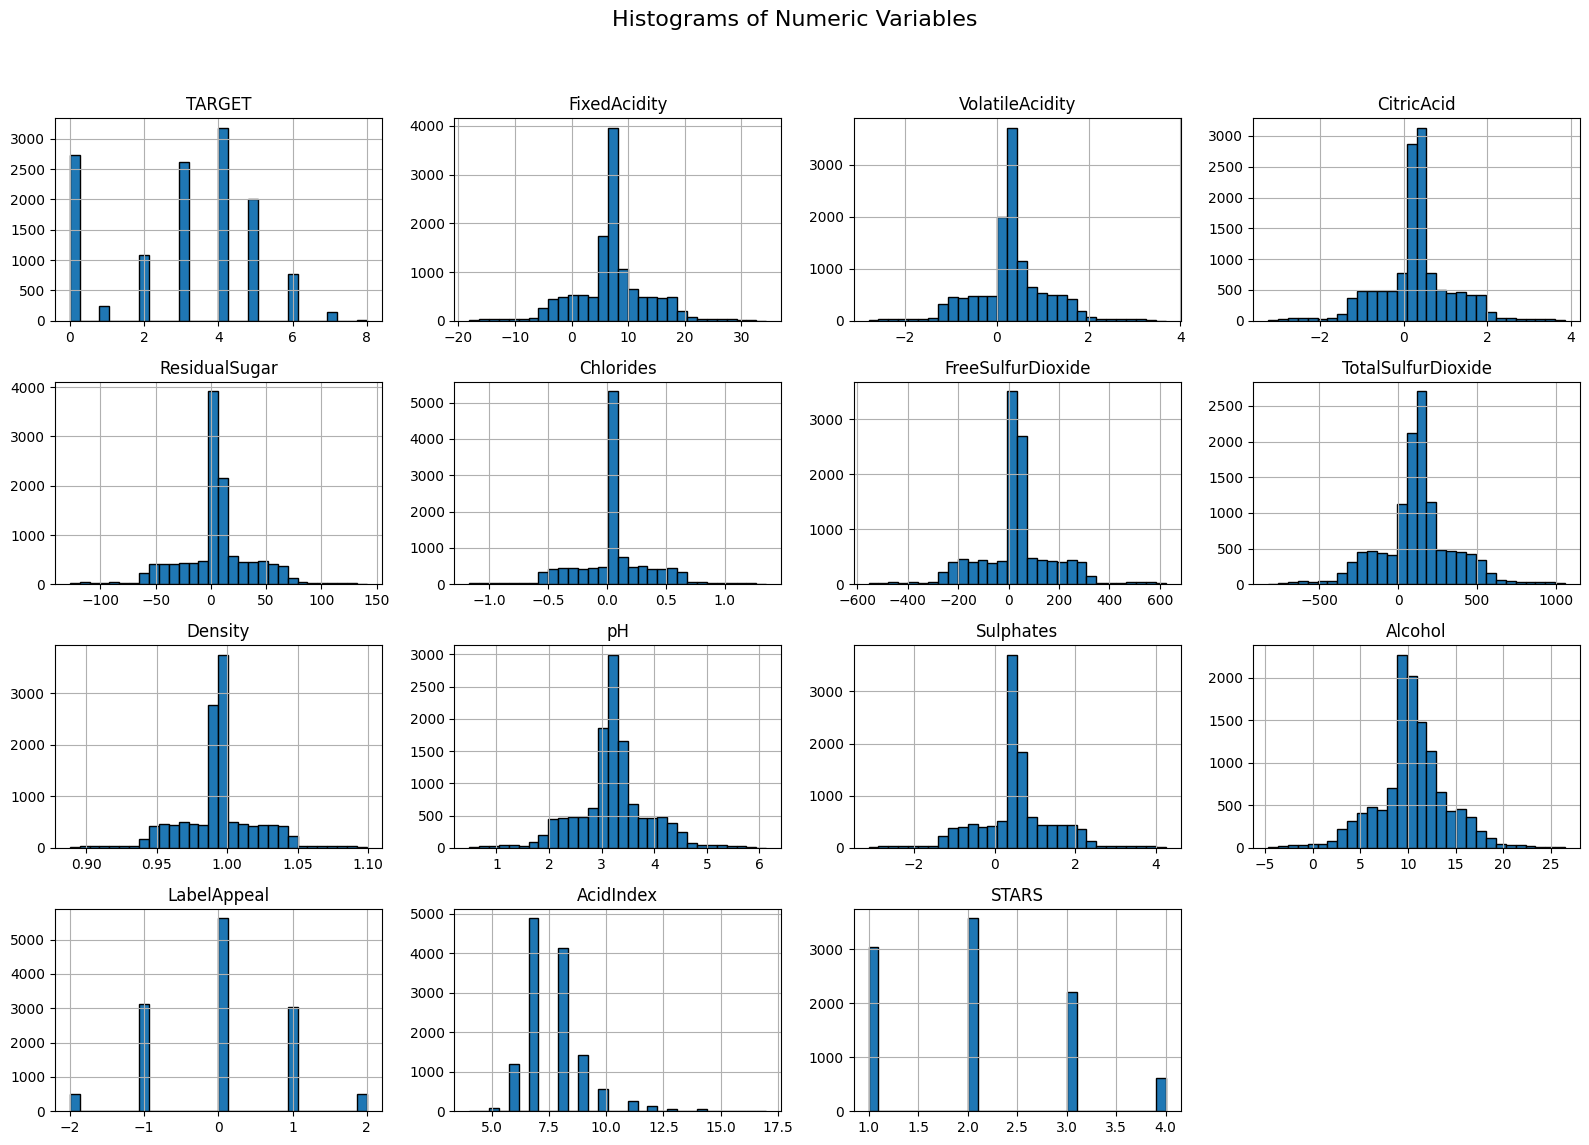

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert numeric-looking columns to numeric
df_num = df.apply(pd.to_numeric, errors="coerce")

# Drop non-numeric columns
num_cols = df_num.select_dtypes(include=["int64","float64"]).columns

# Histograms
df_num[num_cols].hist(bins=30, figsize=(16,12), edgecolor="black")
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Findings:**

Since the dataset has many variables, We started with histograms to check the frequency distribution before moving to boxplots. This gave us a quick overview of how the data is spread and where issues might exist.

**Key takeaways:**


*  Some variables are roughly normal (FixedAcidity, pH, Alcohol).

*   Others show heavy tails/outliers (ResidualSugar, Chlorides, SulfurDioxide).
*   A few numeric columns are actually categorical (LabelAppeal, STARS, Target).


*   Some features contain negative values that don’t make sense (CitricAcid, Sulfur compounds).

*   Target variable shows class imbalance.

### **2.3.2 Skewness Graphs**

Skewness measures the symmetry of a distribution, showing whether data is balanced, left-skewed, or right-skewed.

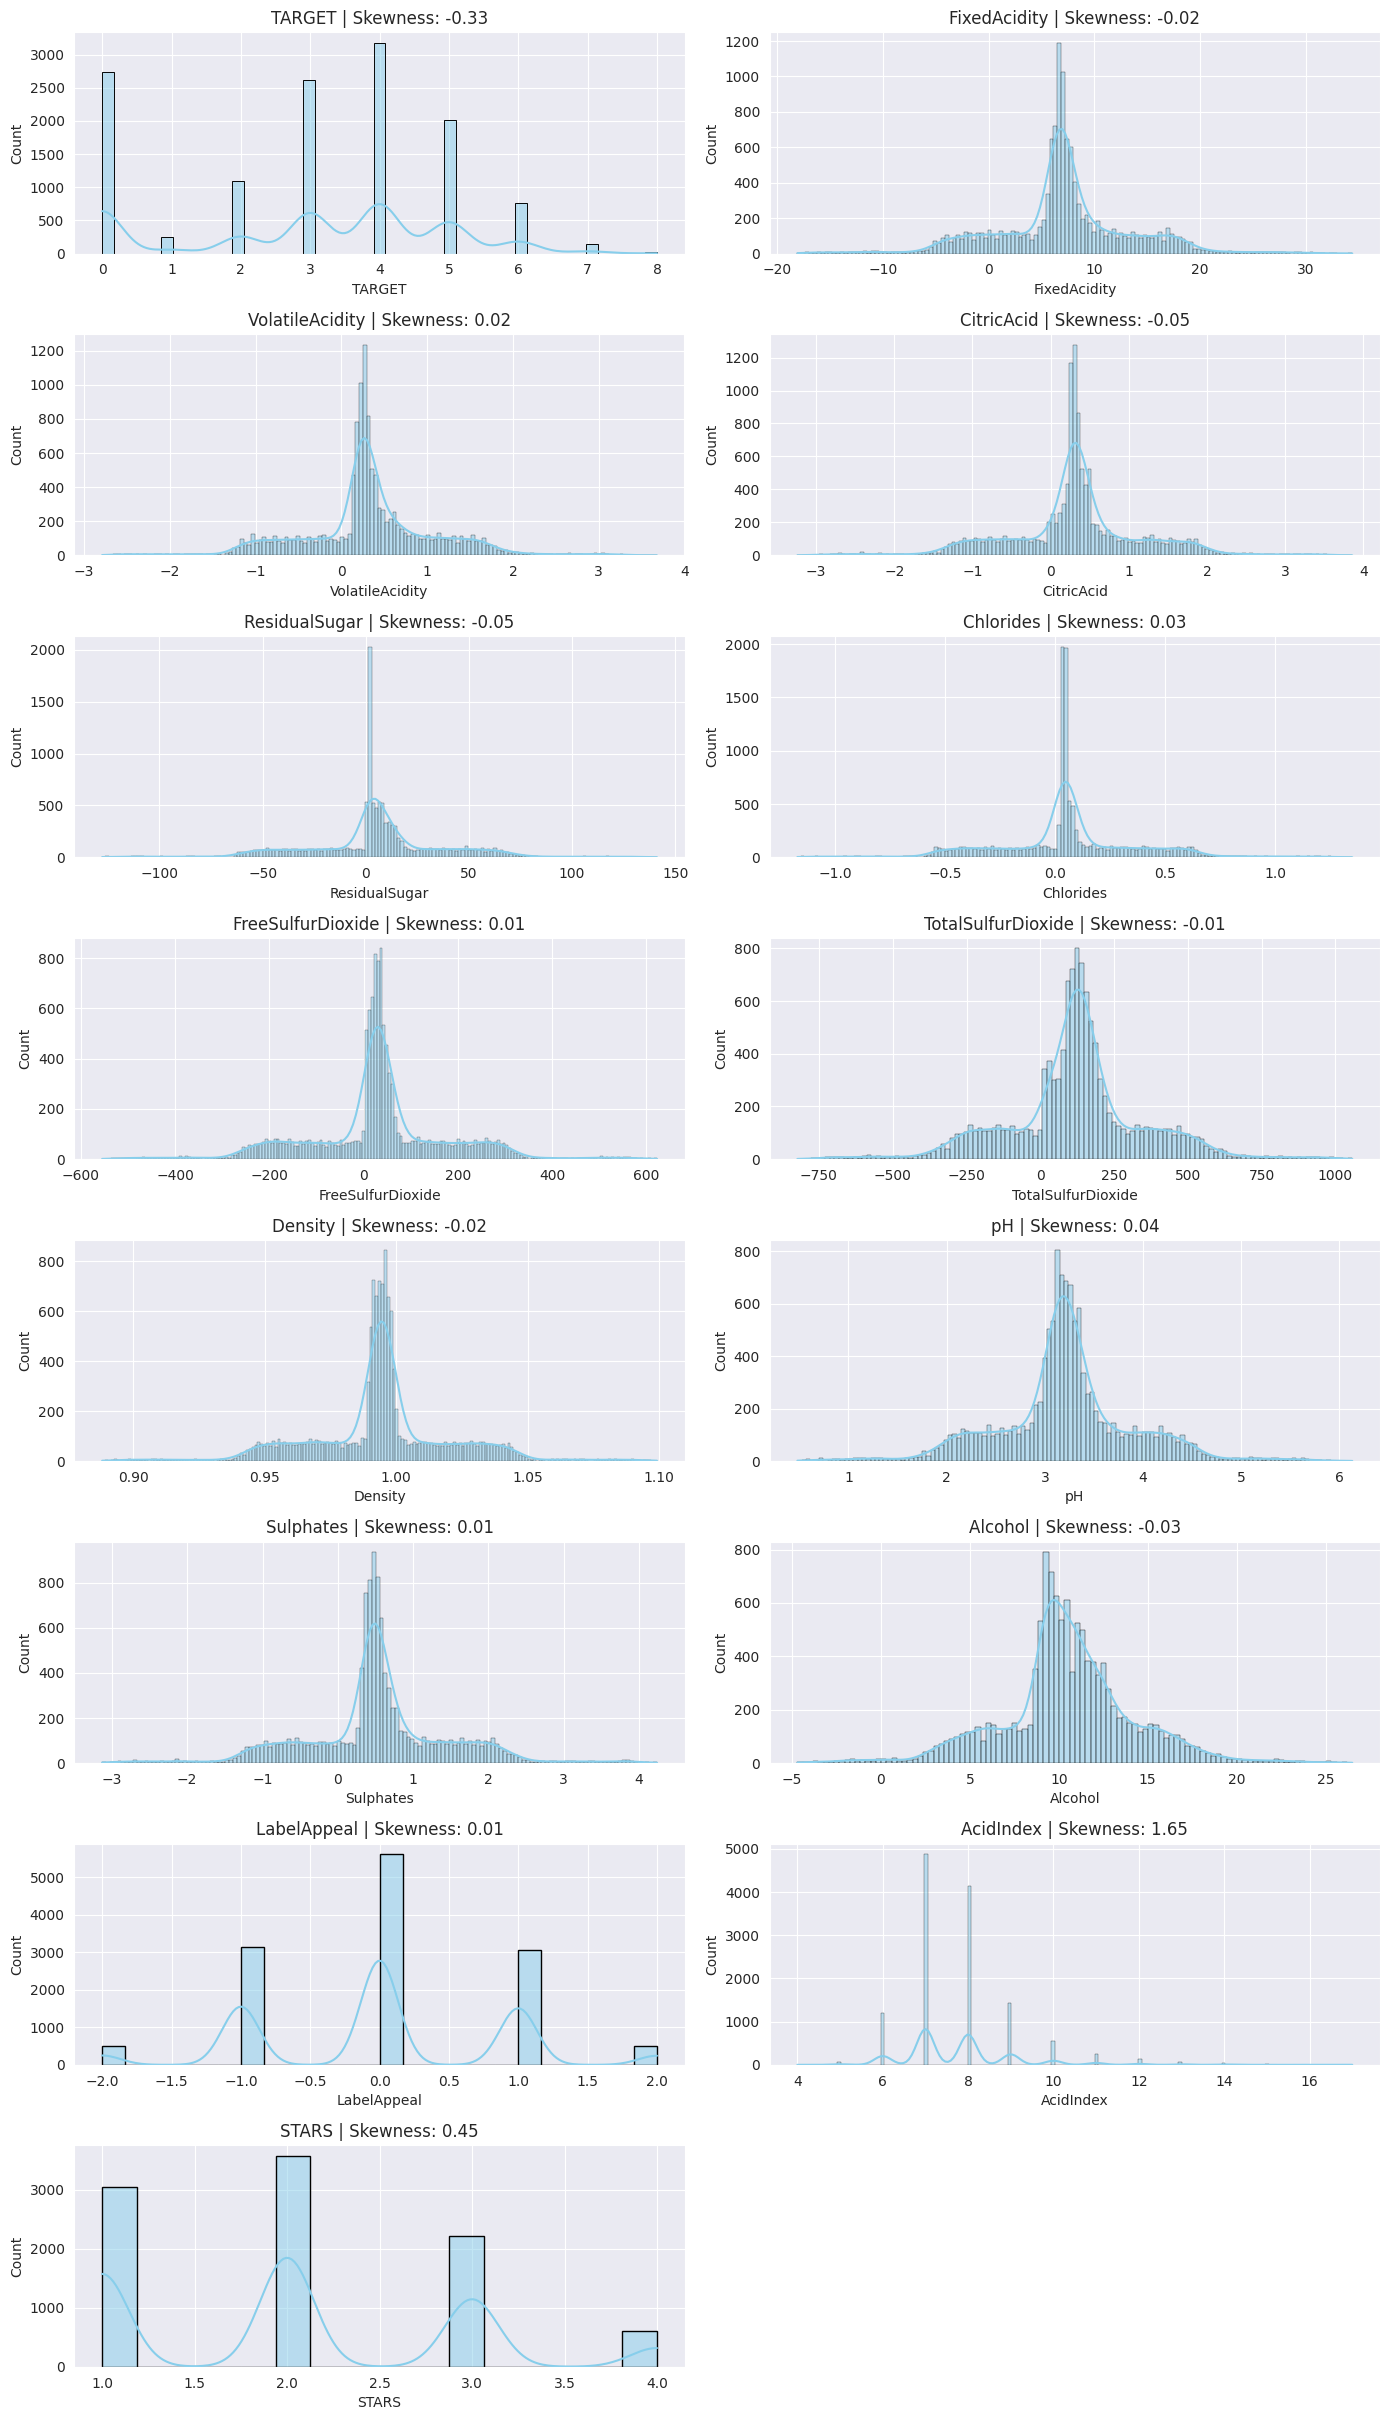

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert numeric-looking columns to numeric
df_num = df.apply(pd.to_numeric, errors="coerce")

# Select numeric columns only
num_cols = df_num.select_dtypes(include=["int64","float64"]).columns

# Set style
sns.set_style("darkgrid")

# Plot histograms with KDE + skewness
plt.figure(figsize=(14, len(num_cols) * 3))

for idx, feature in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, idx)  # 2 plots per row
    sns.histplot(df_num[feature].dropna(), kde=True, color="skyblue", edgecolor="black")
    skew_val = round(df_num[feature].skew(), 2)
    plt.title(f"{feature} | Skewness: {skew_val}")

plt.tight_layout()
plt.show()


**Findings:**


* Most variables (FixedAcidity, VolatileAcidity, pH, Alcohol, etc.) show low
skewness and are close to normal.
* AcidIndex has strong positive skew, while STARS shows mild positive skew.

* Target and INDEX are negatively skewed, though these are categorical/ID-like.

* Skewness analysis confirms that a few features may need transformation or scaling before modeling.

### **2.3.3 Boxplots**
 Boxplots display the spread of data, highlighting the median, quartiles, and potential outliers.

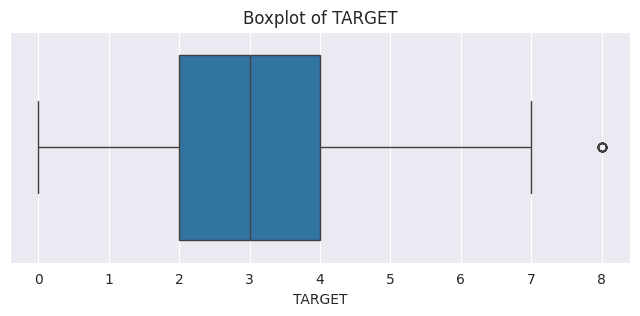

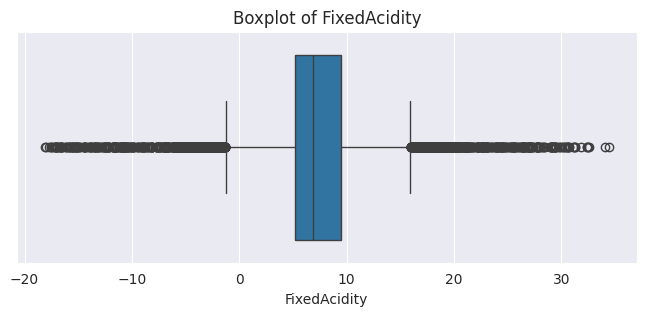

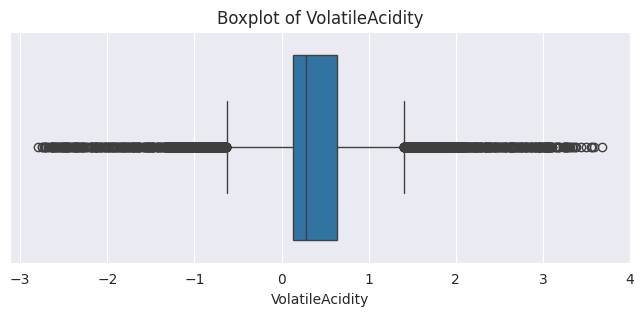

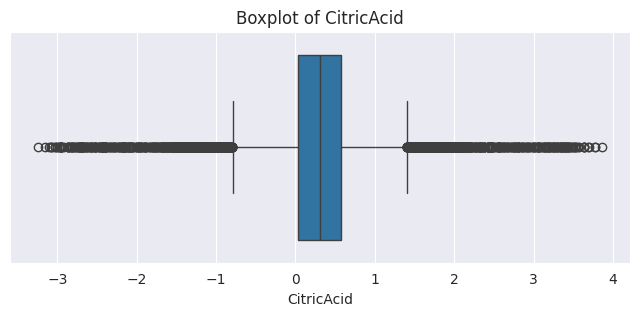

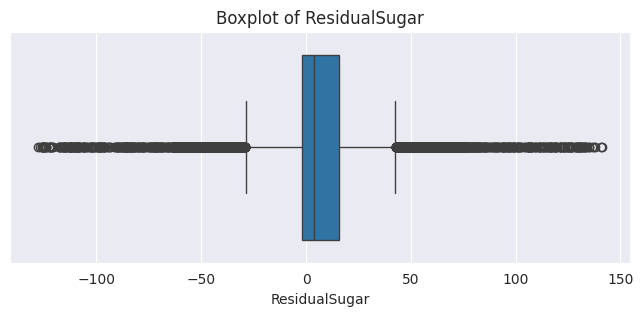

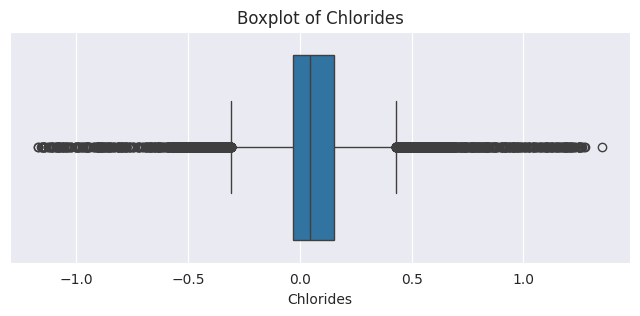

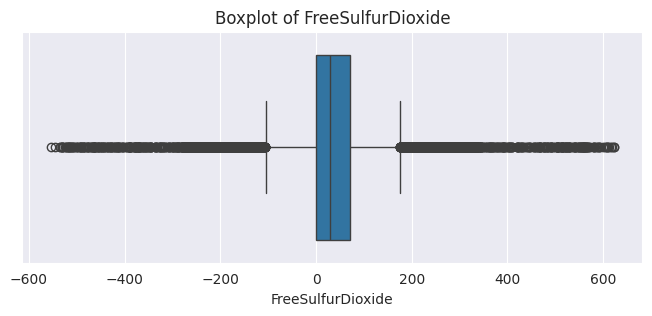

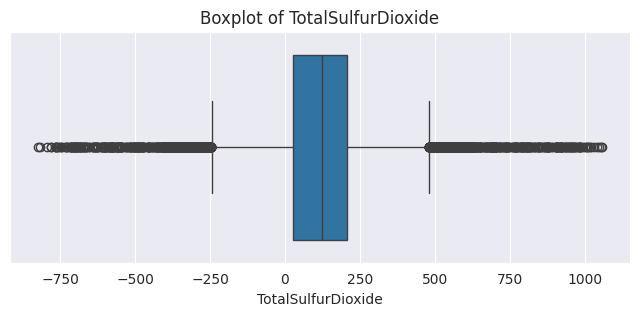

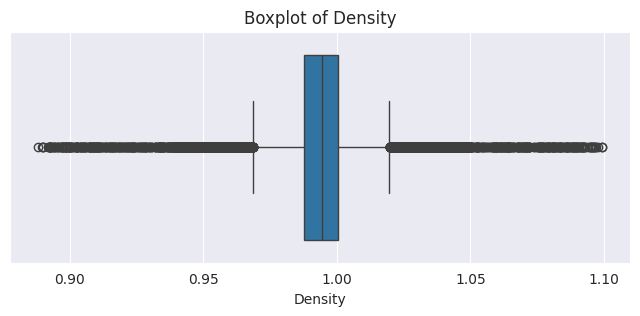

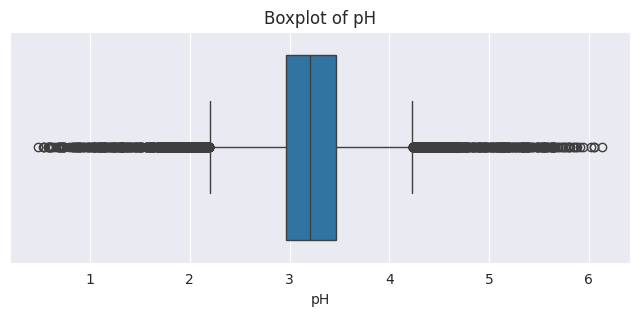

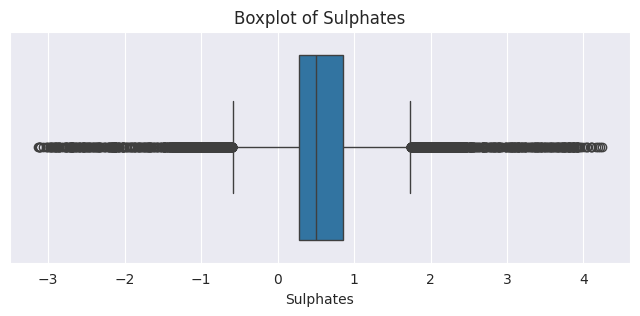

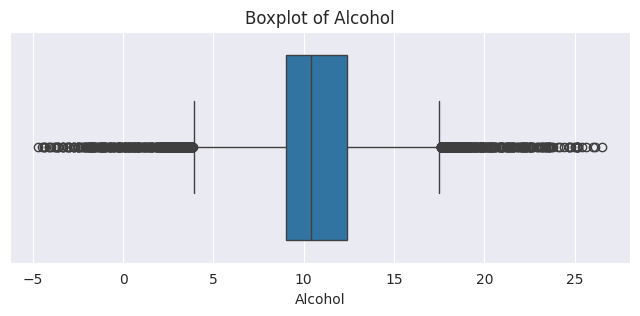

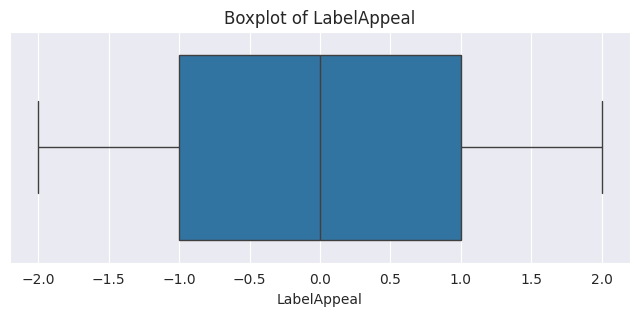

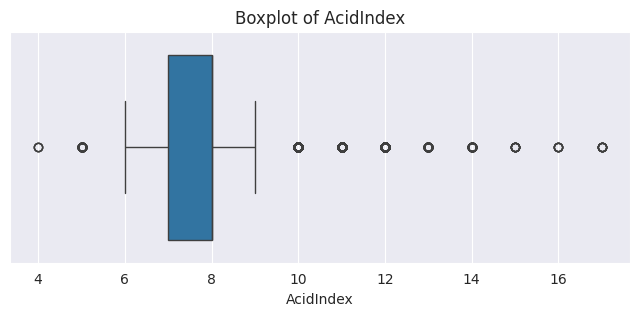

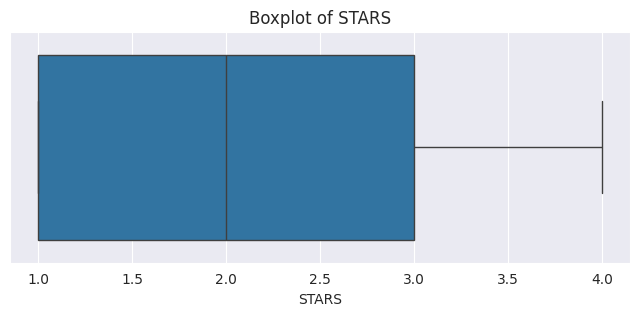

In [7]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_num[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Findings**


*  Many features (ResidualSugar, SulfurDioxide, Chlorides, Alcohol) show a large number of outliers.


*   Some variables have a tight distribution with few outliers (Density, pH).

*   Target and categorical-like variables (LabelAppeal, STARS) show discrete box structures.

*   Negative values are again visible in some features, confirming possible data quality issues.

**Overall, the data has high variability and outliers, which need handling before modeling.**

###**2.3.4 Count plots**

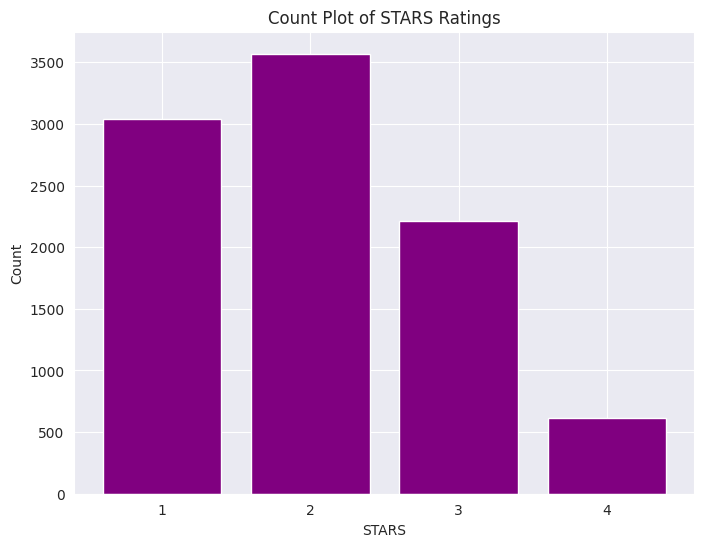

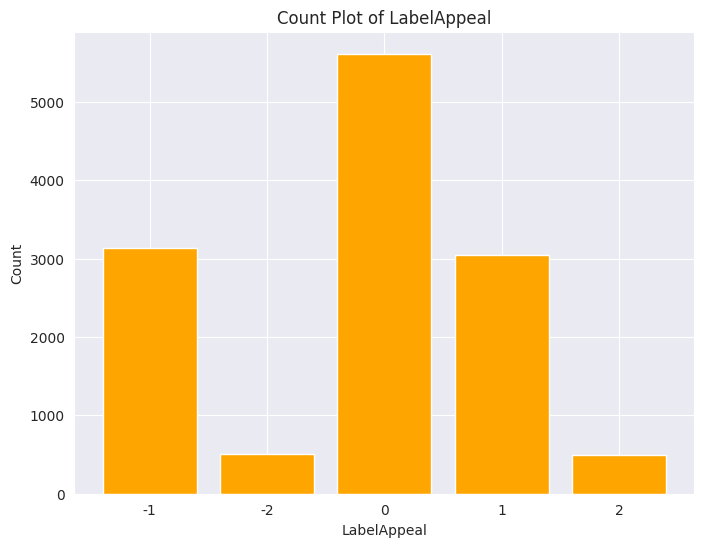

In [8]:
# Count plot of STARS
stars_counts = df["STARS"].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(stars_counts.index, stars_counts, color="purple")
plt.title("Count Plot of STARS Ratings")
plt.xlabel("STARS")
plt.ylabel("Count")
plt.show()


# Count plot of LabelAppeal

appeal_counts = df["LabelAppeal"].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.bar(appeal_counts.index, appeal_counts, color="orange")
plt.title("Count Plot of LabelAppeal")
plt.xlabel("LabelAppeal")
plt.ylabel("Count")
plt.show()


**Findings:**  
Count plots showed the distribution of categorical variables. Most wines have a LabelAppeal of 0 and STARS ratings of 1 or 2, with fewer in higher categories.

###**2.3.5 Correlation Heatmap**
 A correlation heatmap shows the strength and direction of linear relationships between variables. Values range from -1 (negative correlation) to +1 (positive correlation), with 0 meaning no correlation.

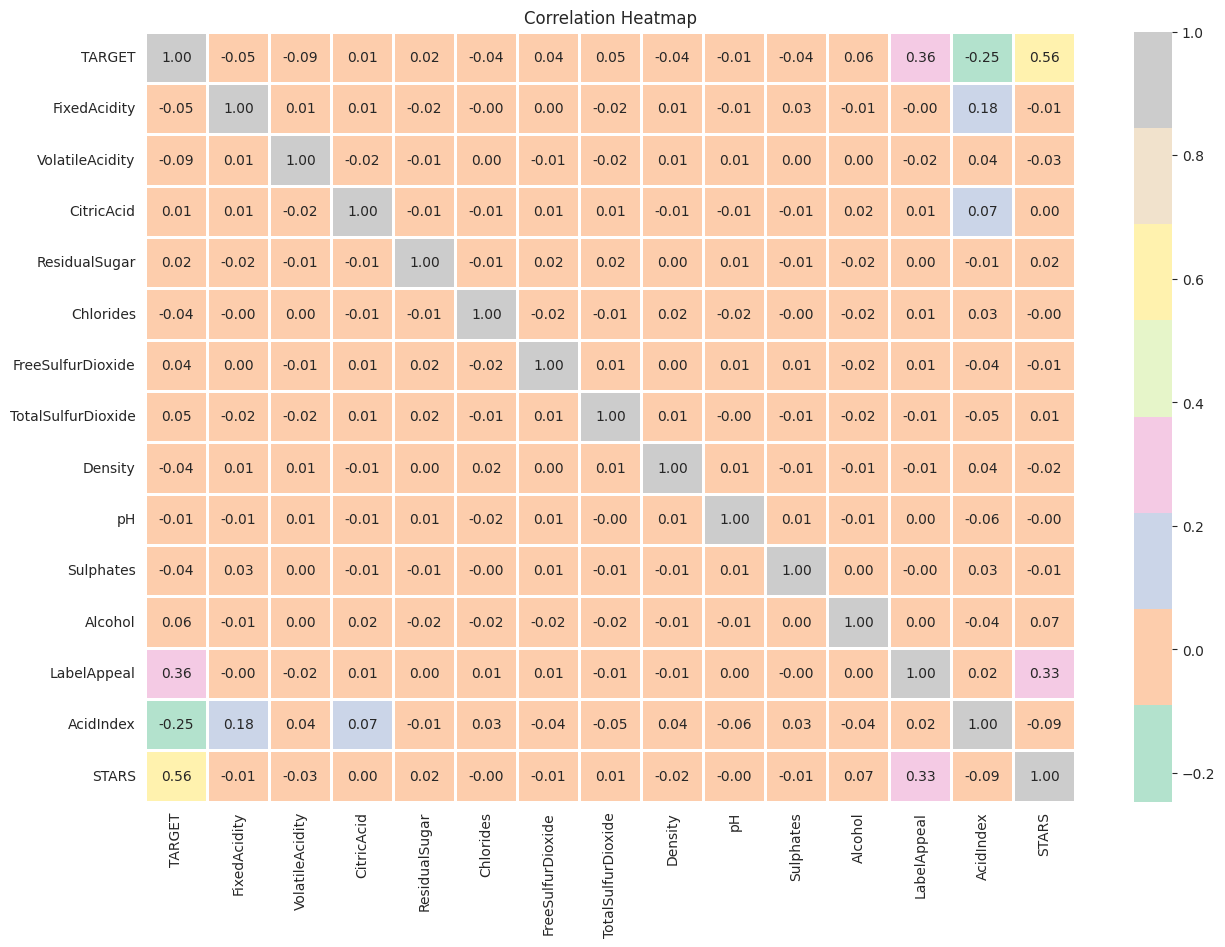

In [9]:
#Correlation values range from -1 to +1:
plt.figure(figsize=(15, 10))

# Plot heatmap with annotated correlation values
# fmt='.2f' ensures values are displayed with 2 decimal places
# cmap='Pastel2' provides a soft color palette
# linewidths=2 separates cells with white lines for clarity

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

**Findings:**



*   TARGET is strongly correlated with STARS (0.56) and moderately with LabelAppeal (0.36).

*   AcidIndex has a negative relation with TARGET (-0.25).

*   Most numeric features show very weak correlations with each other.

##**2.4 Missing Values Summary**

In [10]:
# Missing values summary
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": df.isnull().mean()*100
}).sort_values("Missing_%", ascending=False)
missing


,Missing_Count,Missing_%
STARS,3359,26.252442
Sulphates,1210,9.456819
TotalSulfurDioxide,682,5.330207
Alcohol,653,5.103556
FreeSulfurDioxide,647,5.056663
Chlorides,638,4.986323
ResidualSugar,616,4.814381
pH,395,3.087143
TARGET,0,0.000000
FixedAcidity,0,0.000000


**Findings:**



*   STARS has the highest missing values (~26%), making it a major concern.


*   Sulphates (9%) and a few chemical measures (~5%) also have notable gaps.



## **EDA Summary**

Exploratory Data Analysis (EDA) revealed several important insights about the wine dataset:

- **Data Integrity Issues**:  
  - Negative values were detected in multiple chemical attributes (e.g., ResidualSugar, Chlorides, FreeSulfurDioxide, TotalSulfurDioxide), which are physically invalid.  
  - The STARS  variable contained the highest level of missingness (~26%), making it the least reliable in raw form.  
  - A subset of wines showed unrealistic `Alcohol` values (<5% or >20%).  

- **Distributional Characteristics**:  
  - Most variables (FixedAcidity, pH, Density, Sulphates) were approximately symmetric.  
  - **AcidIndex** was severely right-skewed (skewness > 1.5), making it a strong candidate for transformation.  
  - `TARGET` (sales) was slightly left-skewed but not extreme.  
  - Boxplots confirmed the presence of numerous outliers across several numeric variables.  

- **Categorical Variables**:  
  - `STARS` and `LabelAppeal` showed imbalanced distributions, with most wines clustered in only a few categories.  
  - These features appear more influential than raw chemistry in explaining differences in `TARGET`.  

- **Relationships Between Variables**:  
  - The correlation heatmap indicated weak to moderate relationships among chemical attributes.  
  - Stronger associations were observed between `TARGET` and perceptual features such as `STARS` and `LabelAppeal`, suggesting these may be key drivers of wine sales.  

**Conclusion:**  
The dataset in its raw form contains integrity issues, outliers, and skewed distributions that must be addressed before modeling. The next step is **data preparation**, including imputing missing values, correcting invalid entries, and applying transformations to skewed attributes to improve data usability for machine learning.  


# **3.Data Preparation**
Now, after identifying the issues with the data we're going to fix them by applying various techniques to remove missing values, outliers and extreme skewness.

###**3.1 Seperating Response and Explanatory Variable**

In [11]:
# seperating response and explanatory variable
X = df.drop(columns=['TARGET'], errors='ignore')
y = df['TARGET']


###**3.2 Removing Missing Data**


1.    List of all columns that need to be converted to numeric
2. LabelAppeal's negative value is not removed because we're considering it as  a range from it's negative extreme to its positive extreme
3. STARS is an ordinal categorical variable.





In [12]:


cols_to_convert = [
    'FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
    'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
    'Density', 'pH', 'Sulphates', 'Alcohol', 'AcidIndex',
]

# We're converting all specified columns to numeric and handled negative values
for col in cols_to_convert:
    X[col] = pd.to_numeric(X[col], errors='coerce')

    #  handling the negative values by replacing them with NaN
    X.loc[X[col] < 0, col] = np.nan

# Convert STARS to integer
X['STARS'] = pd.to_numeric(X['STARS'], errors='coerce')
X['STARS'] = X['STARS'].astype('Int64')

# Convert LabelAppeal to float
X['LabelAppeal'] = pd.to_numeric(X['LabelAppeal'], errors='coerce')
X['LabelAppeal'] = X['LabelAppeal'].astype('Float64')

# Check the data types to confirm the conversion
print(X.dtypes)

FixedAcidity          float64
VolatileAcidity       float64
CitricAcid            float64
ResidualSugar         float64
Chlorides             float64
FreeSulfurDioxide     float64
TotalSulfurDioxide    float64
Density               float64
pH                    float64
Sulphates             float64
Alcohol               float64
LabelAppeal           Float64
AcidIndex             float64
STARS                   Int64
dtype: object


In [13]:
# In the code below we're imputing the missing data. We're applying mode imputation for categorical data and median imputation for numeric.
for col in X.columns:
    if col == 'STARS':
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

In [14]:
X.isnull().sum()

,0
FixedAcidity,0
VolatileAcidity,0
CitricAcid,0
ResidualSugar,0
Chlorides,0
FreeSulfurDioxide,0
TotalSulfurDioxide,0
Density,0
pH,0
Sulphates,0


**Findings:**

The initial analysis showed
     that several columns had a significant percentage of missing values like the STARS column that has over 26% missing. So the approach of imputation is considered to solve the issue of missing data.

###**3.3 Removing Outliers**

Here, summary statistics show several columns with high positive skewness and extreme maximum values, suggesting the presence of significant outliers.
For instance, ResidualSugar, FreeSulfurDioxide, and TotalSulfurDioxide have maximum values that are many standard deviations away from their means.
So we're treating the outliers using the Interquartile Range method.

In [15]:
# List of columns to check for outliers
cols_to_cap = [
    'FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
    'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
    'Sulphates', 'Alcohol', 'pH', 'Density', 'LabelAppeal', 'AcidIndex'
]

for col in cols_to_cap:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping the outliers
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])


In [16]:
# Summary Statistics
numeric_cols = X.select_dtypes(include=np.number).columns

if len(numeric_cols) == 0:
    print("No numeric columns available for summary.")
else:
    stats = X[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
    stats["median"] = X[numeric_cols].median()
    stats["IQR"] = X[numeric_cols].quantile(0.75) - X[numeric_cols].quantile(0.25)
    stats["missing_count"] = X[numeric_cols].isnull().sum()
    stats["missing_%"] = (X[numeric_cols].isnull().mean() * 100).round(2)
    stats["skewness"] = X[numeric_cols].skew()
    print(stats)

print(X.dtypes)


                      count        mean        std       min      25%  \
FixedAcidity        12795.0     8.01966   3.322048      1.75      6.4   
VolatileAcidity     12795.0     0.49976   0.343811       0.0     0.27   
CitricAcid          12795.0    0.480056   0.282635       0.0      0.3   
ResidualSugar       12795.0   11.832278   9.824602       0.0      4.7   
Chlorides           12795.0    0.100463   0.080122       0.0    0.048   
FreeSulfurDioxide   12795.0   53.252013  33.989973       0.0     31.0   
TotalSulfurDioxide  12795.0  166.090387  85.216721       0.0    116.0   
Density             12795.0    0.994187   0.016023  0.968527  0.98772   
pH                  12795.0    3.206206   0.530203      2.25     2.97   
Sulphates           12795.0    0.661045   0.291819      0.07     0.49   
Alcohol             12795.0   10.561858   3.052833      4.45      9.1   
LabelAppeal         12795.0   -0.009066   0.891089      -2.0     -1.0   
AcidIndex           12795.0    7.653732   0.986885 

**Findings:**

The descriptive statistics
     revealed the presence of extreme values in several columns. For e.g.,
     FixedAcidity, ResidualSugar,
     FreeSulfurDioxide, TotalSulfurDioxide.
     Outliers can have a disproportionately large
     influence on the results of the analysis and can skew the predictions of the model. Removing them will create a more robust and accurate model.

### **3.4 Log Transformation**

Outlier capping significantly reduced the skewness in some features, but several still have a skewness value greater than 0.5. so we're applying log transformation.

In [17]:
cols_to_transform = [
    'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
    'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
    'Sulphates', 'LabelAppeal'
]

# Applying the log transformation to the specified columns
for col in cols_to_transform:
    X[col] = np.log1p(X[col])



/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


 **Findings:**
Even after handling the
     outliers, the analysis of the skewness shows that several of the explanatory variables are still skewed. So we apply a log
     transformation to the skewed
     columns. This is a powerful technique that can
     help to make the distribution of the data more symmetrical.

#**4. Redoing EDA to verify data processing**

###**4.1 Summary Statistics**

In [18]:
# Summary Statistics
numeric_cols = X.select_dtypes(include=np.number).columns

if len(numeric_cols) == 0:
    print("No numeric columns available for summary.")
else:
    stats = X[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
    stats["median"] = X[numeric_cols].median()
    stats["IQR"] = X[numeric_cols].quantile(0.75) - X[numeric_cols].quantile(0.25)
    stats["missing_count"] = X[numeric_cols].isnull().sum()
    stats["missing_%"] = (X[numeric_cols].isnull().mean() * 100).round(2)
    stats["skewness"] = X[numeric_cols].skew()
    print(stats)

print(X.dtypes)


                      count       mean       std       min       25%  \
FixedAcidity        12795.0    8.01966  3.322048      1.75       6.4   
VolatileAcidity     12795.0   0.381946  0.210004       0.0  0.239017   
CitricAcid          12795.0   0.375041  0.181795       0.0  0.262364   
ResidualSugar       12795.0   2.243112  0.821294       0.0  1.740466   
Chlorides           12795.0   0.093209  0.070145       0.0  0.046884   
FreeSulfurDioxide   12795.0   3.773992  0.718907       0.0  3.465736   
TotalSulfurDioxide  12795.0   4.944304  0.688137       0.0  4.762174   
Density             12795.0   0.994187  0.016023  0.968527   0.98772   
pH                  12795.0   3.206206  0.530203      2.25      2.97   
Sulphates           12795.0   0.492775  0.169527  0.067659  0.398776   
Alcohol             12795.0  10.561858  3.052833      4.45       9.1   
LabelAppeal         12291.0       -inf       NaN      -inf       NaN   
AcidIndex           12795.0   7.653732  0.986885       5.5      

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


**From the summary statistics:**

*   Missing Data has been handeled
*   Outliers removed significantly
*   Lower skewness overall from before


###**4.2 Histogram**

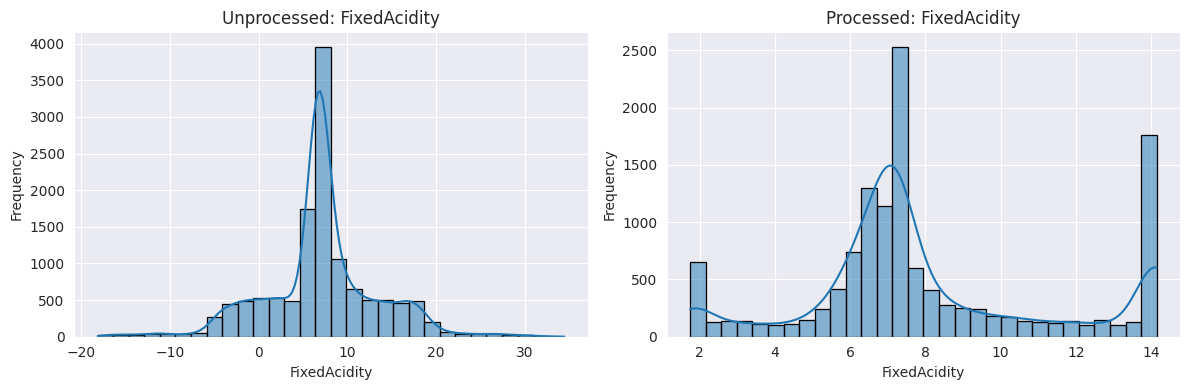

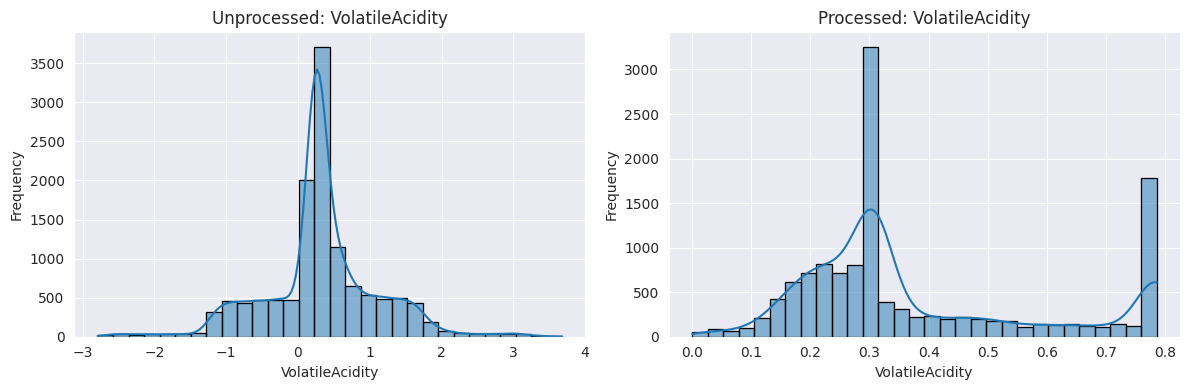

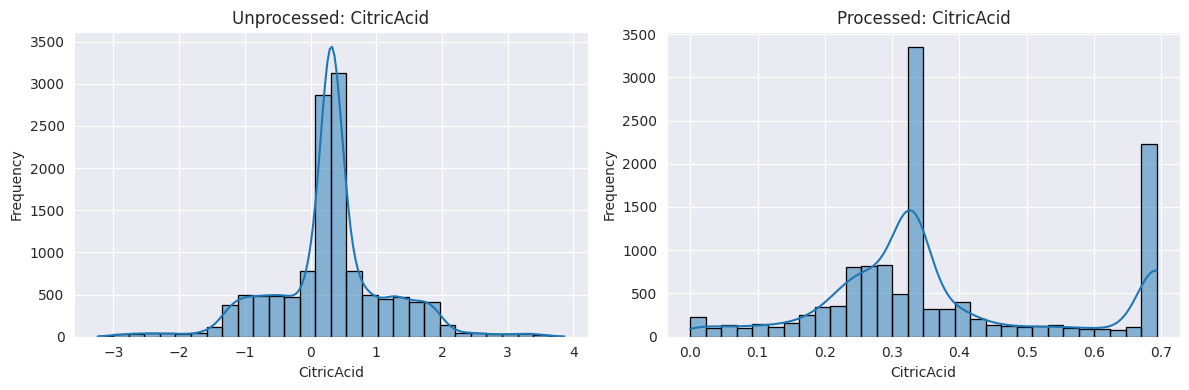

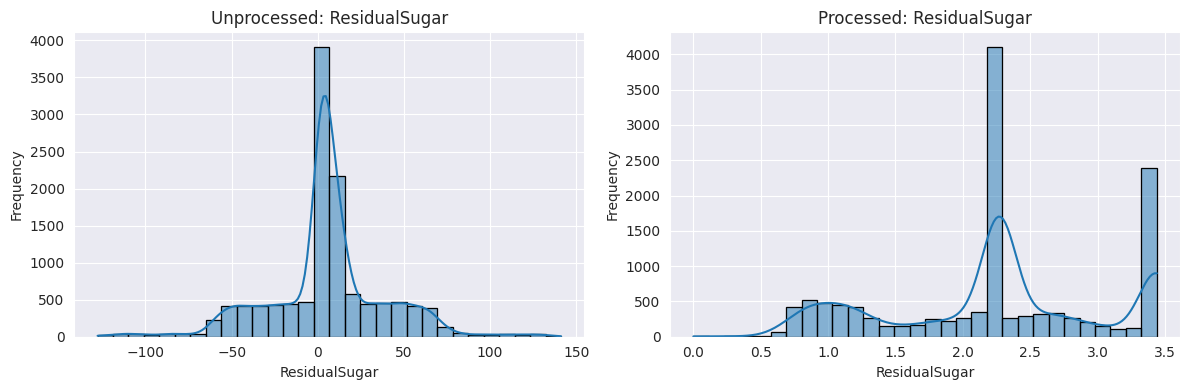

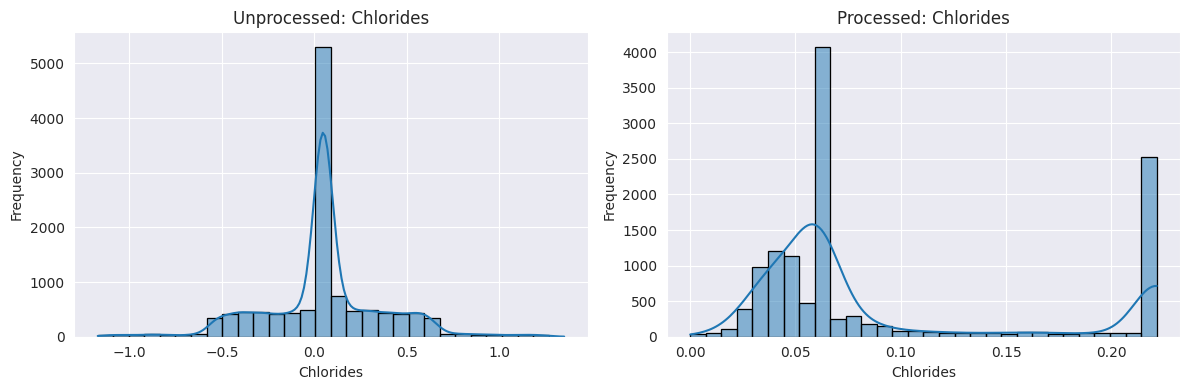

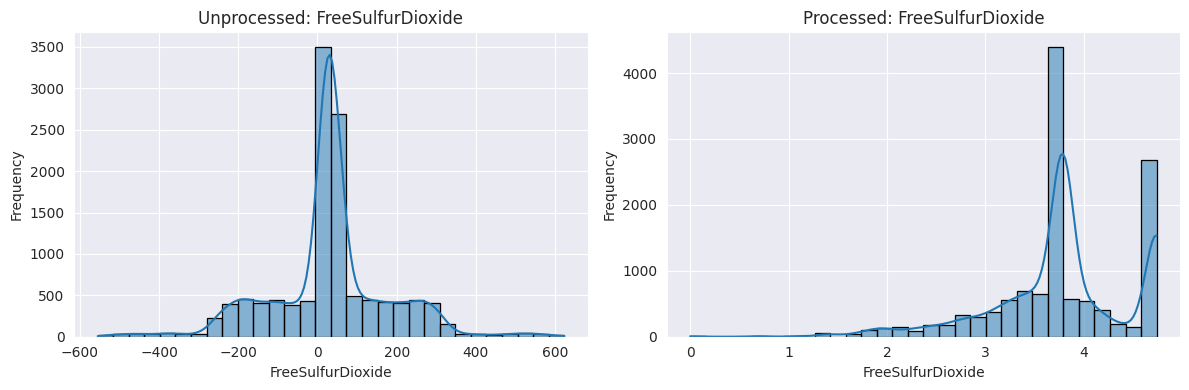

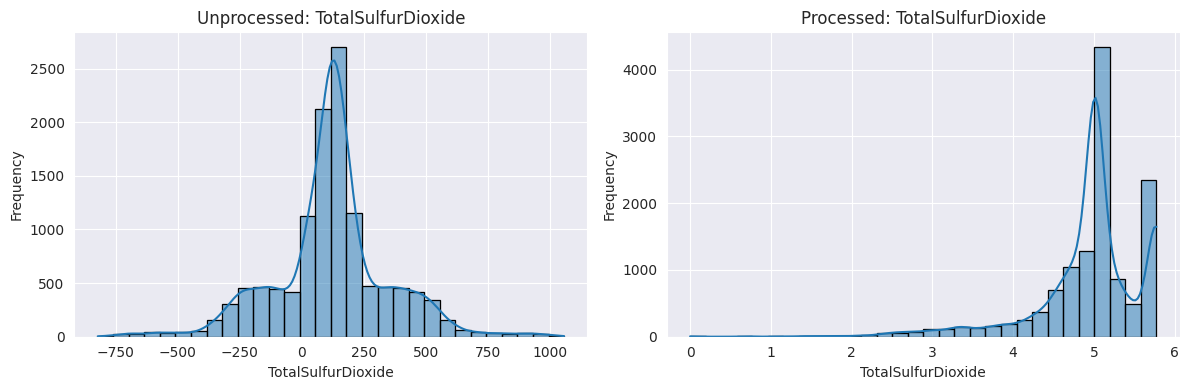

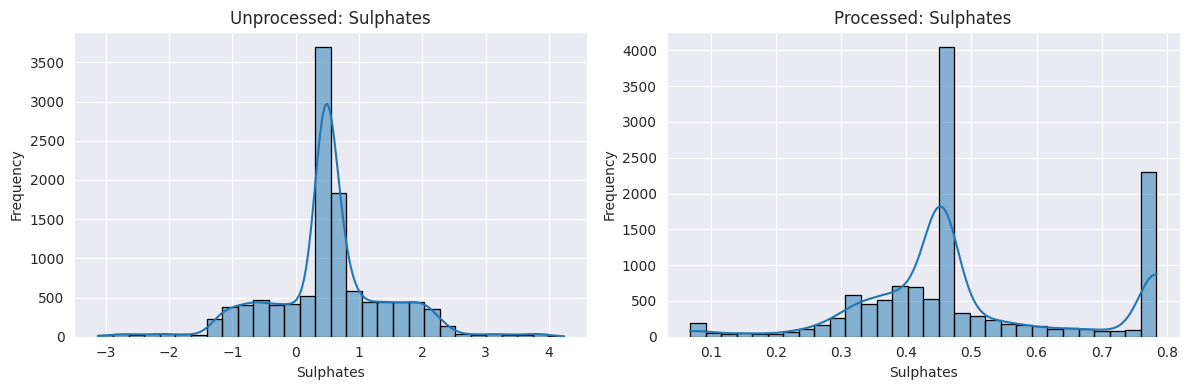

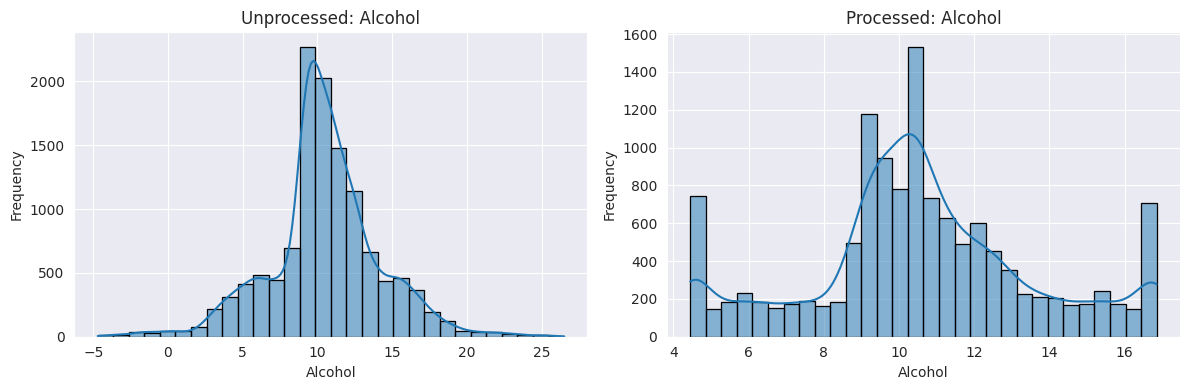

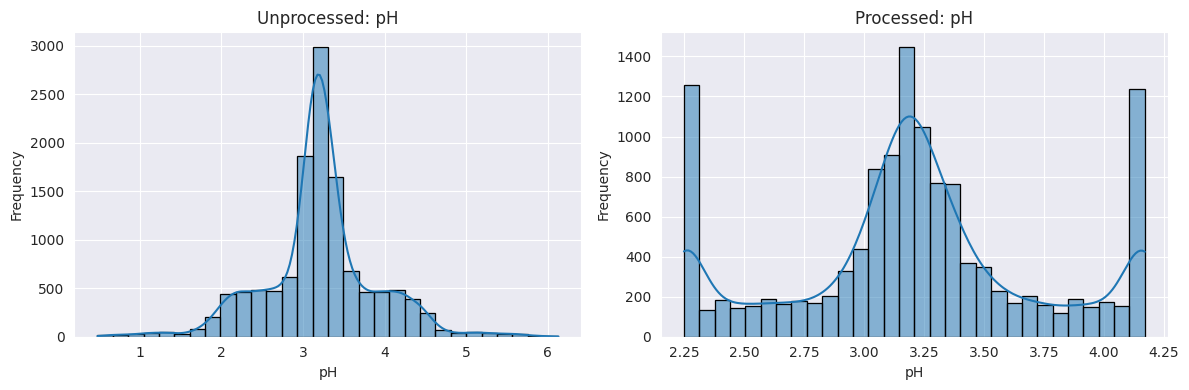

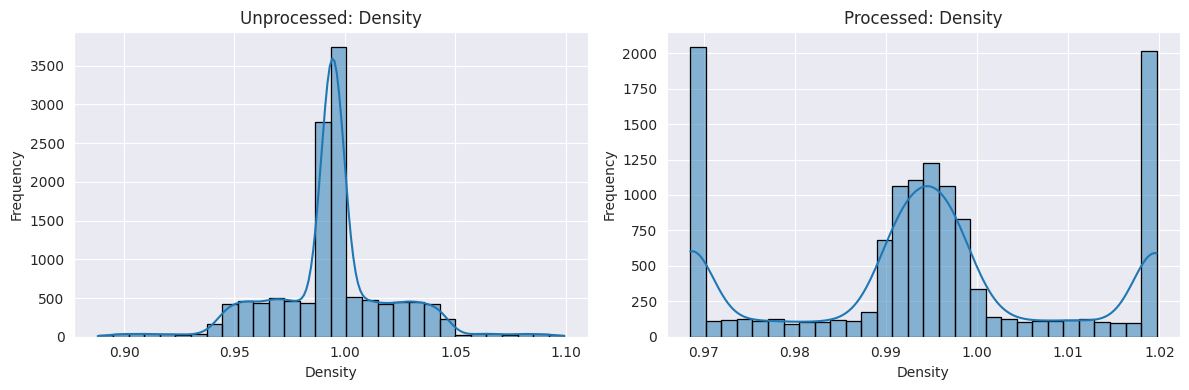

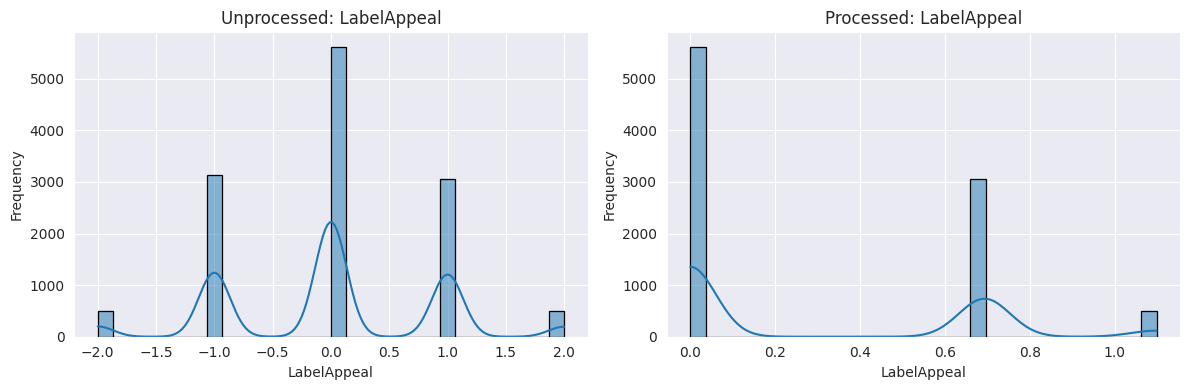

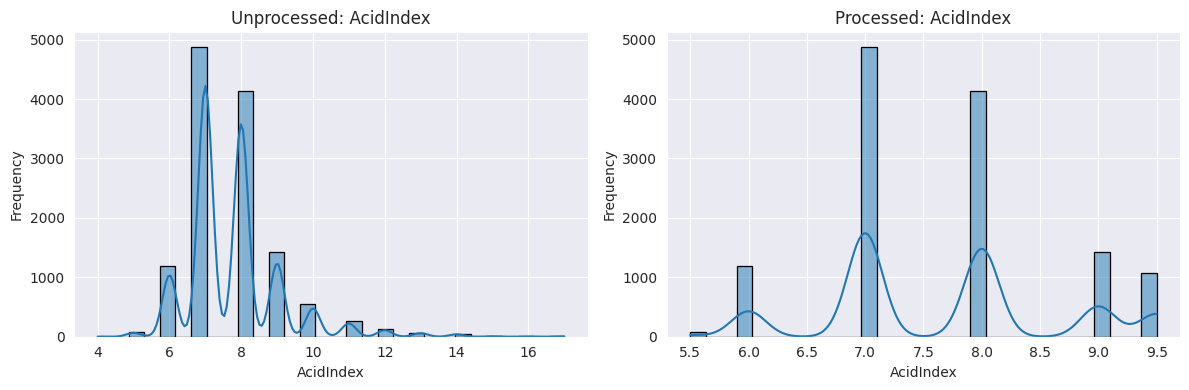

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Columns to plot histograms for
cols_to_plot = [
    'FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
    'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
    'Sulphates', 'Alcohol', 'pH', 'Density', 'LabelAppeal', 'AcidIndex'
]

# Ensure the columns in both DataFrames are numeric
for col in cols_to_plot:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Plot histograms for each column
for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot histogram for unprocessed data
    sns.histplot(df[col], kde=True, bins=30, edgecolor="black", ax=axes[0])
    axes[0].set_title(f'Unprocessed: {col}')
    axes[0].set_ylabel('Frequency')

    # Plot histogram for processed data
    sns.histplot(X[col], kde=True, bins=30, edgecolor="black", ax=axes[1])
    axes[1].set_title(f'Processed: {col}')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

**From the Histogram:**

*   Some distributions have been normalized
*   Over correction from the log transformation can also be observed for some features.



###**4.3 Skewness Graph**

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


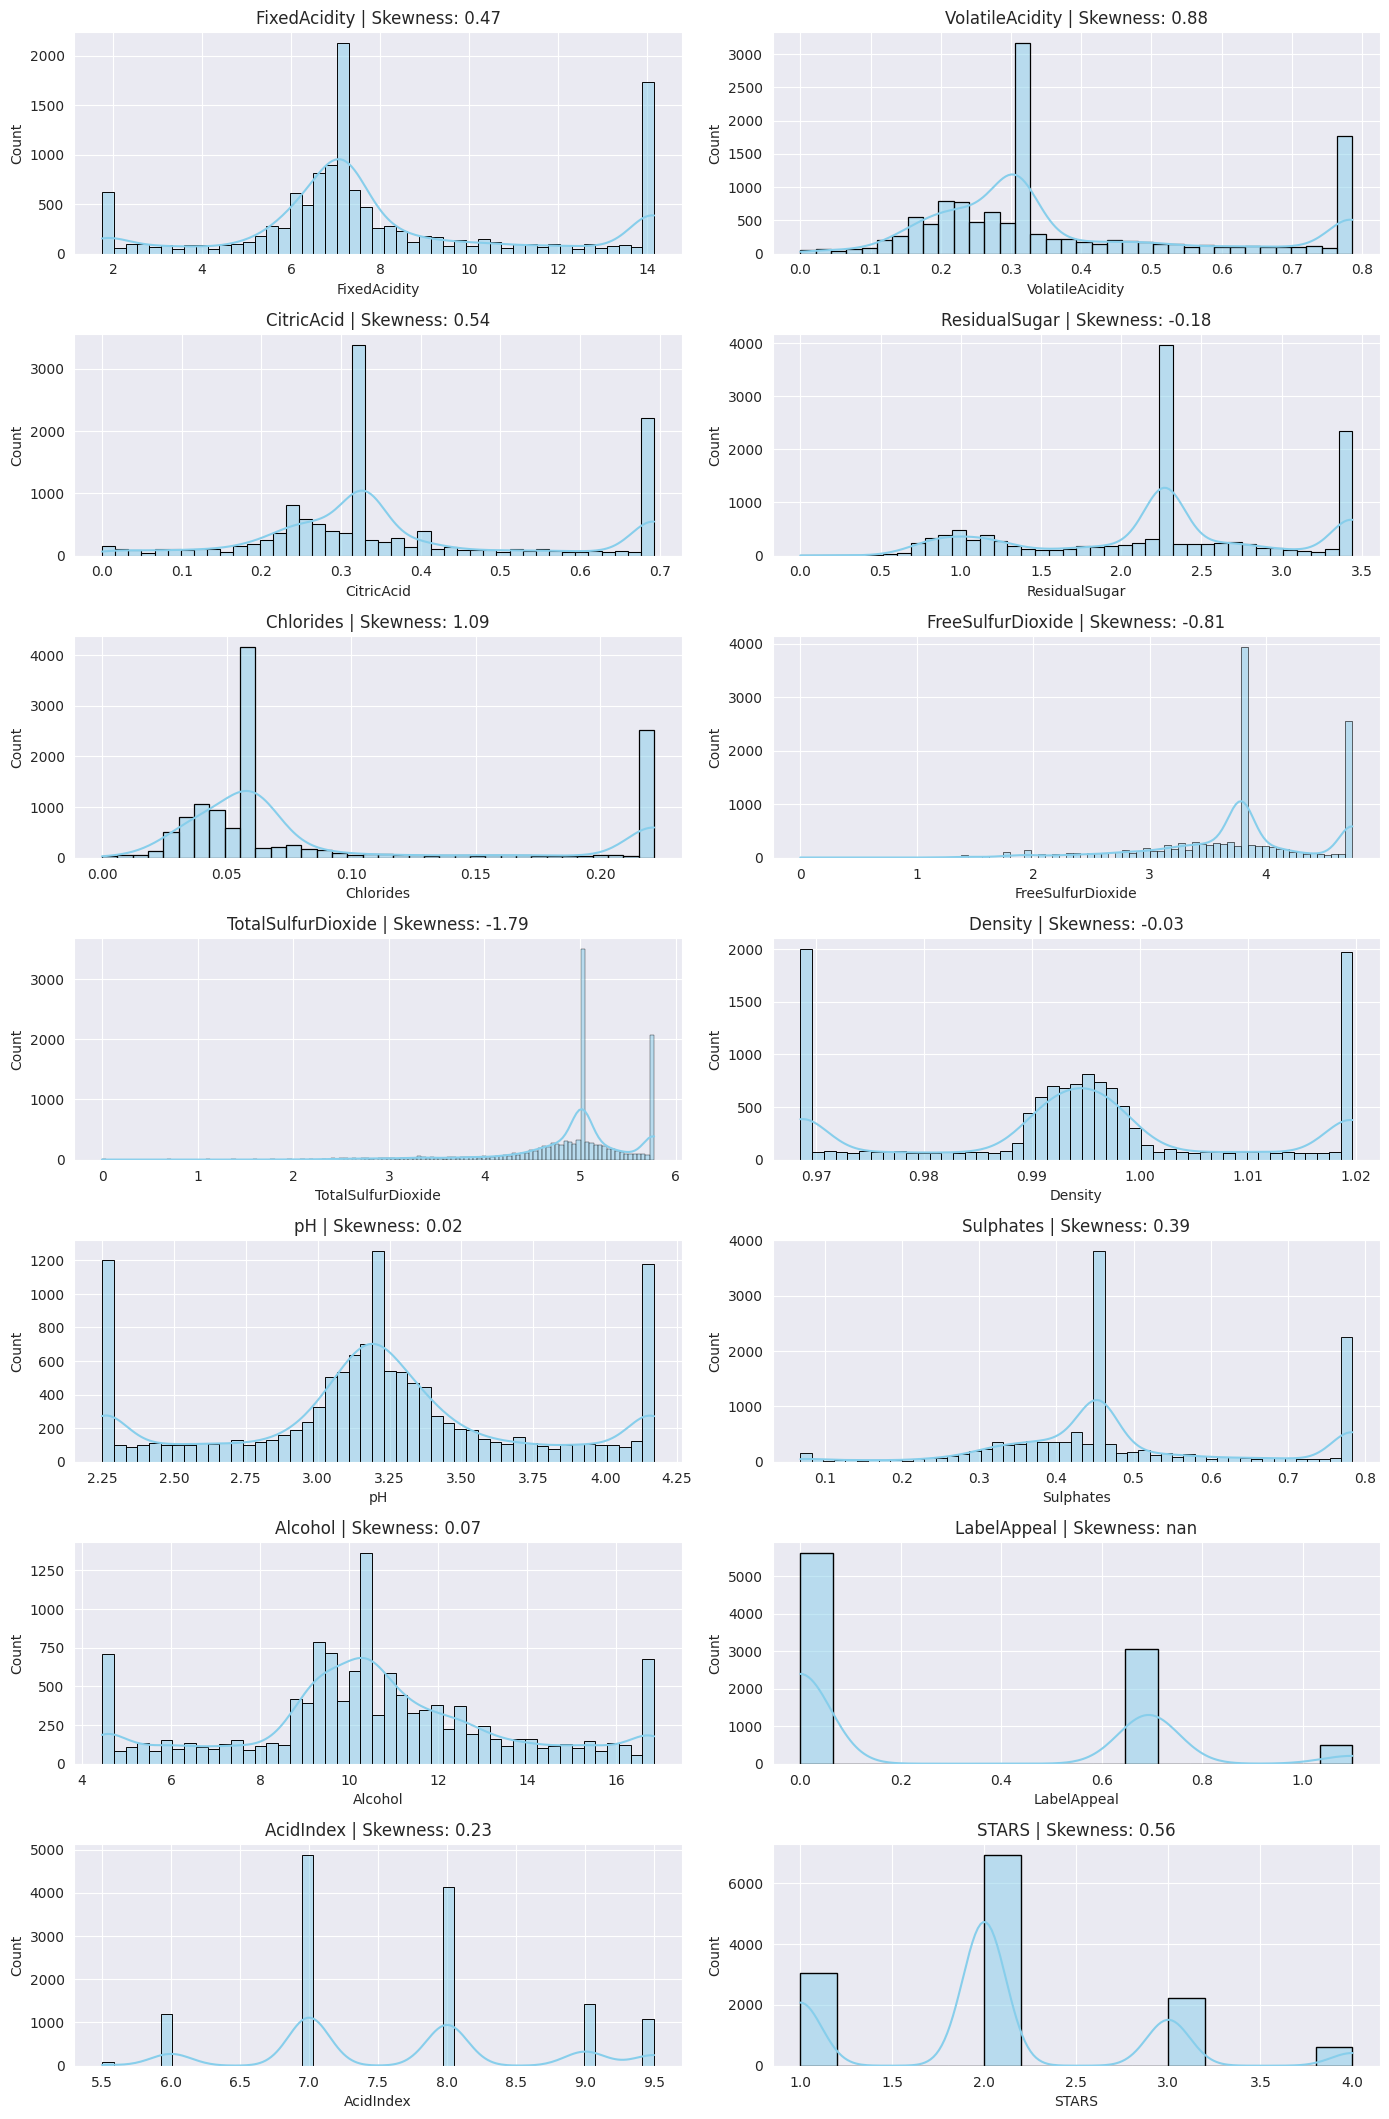

In [20]:
#Skewness Graph

# Convert numeric-looking columns to numeric
df_num = X.apply(pd.to_numeric, errors="coerce")

# Select numeric columns only
num_cols = df_num.select_dtypes(include=["int64","float64"]).columns

# Set style
sns.set_style("darkgrid")

# Plot histograms with KDE + skewness
plt.figure(figsize=(14, len(num_cols) * 3))

for idx, feature in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, idx)  # 2 plots per row
    sns.histplot(df_num[feature].dropna(), kde=True, color="skyblue", edgecolor="black")
    skew_val = round(df_num[feature].skew(), 2)
    plt.title(f"{feature} | Skewness: {skew_val}")

plt.tight_layout()
plt.show()

**From the Skewnees Graph:**


*   We've been able to reduce extreme skewnees for most of the features.



###**4.4 Boxplot**

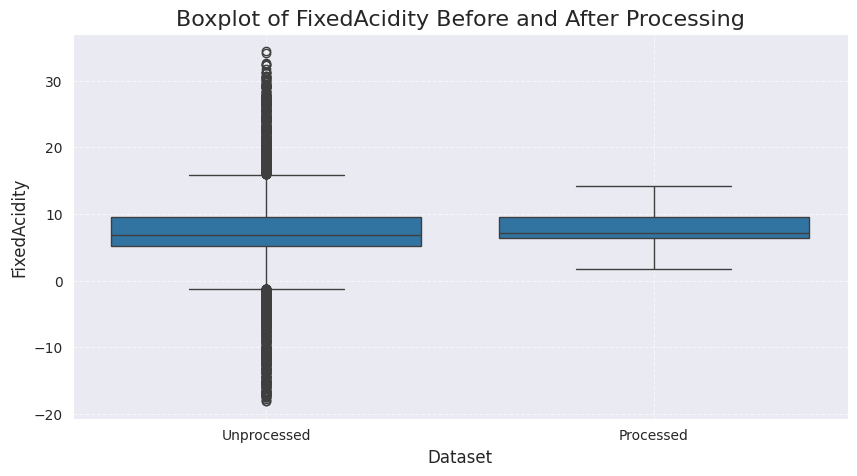

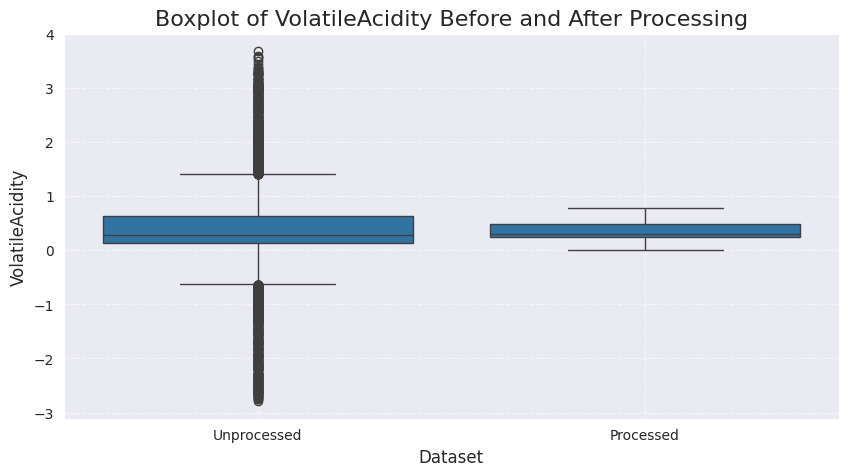

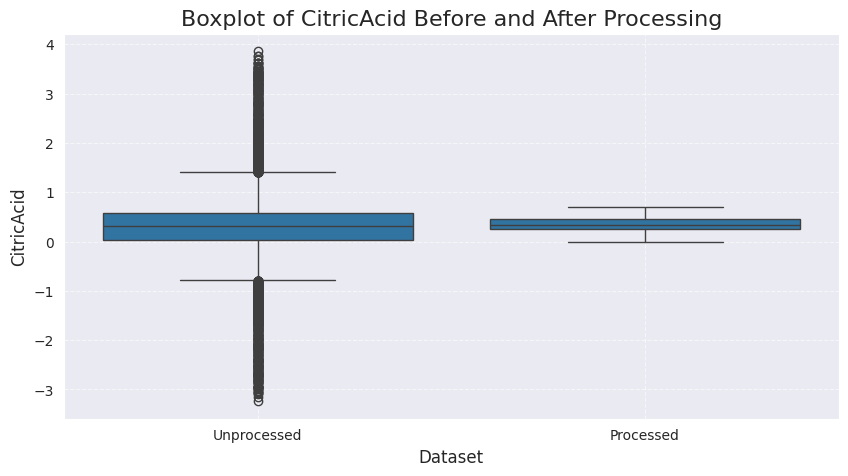

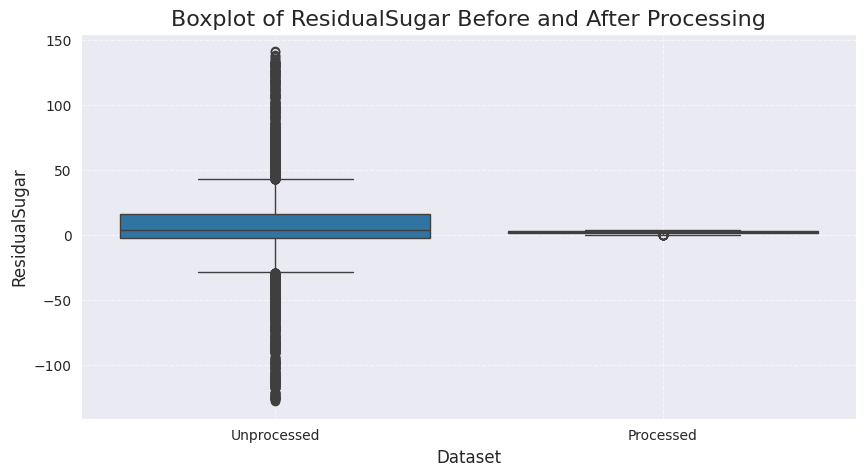

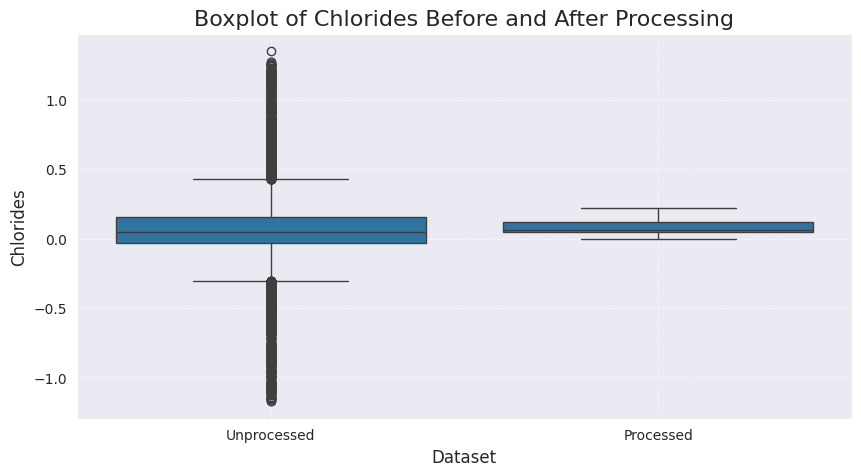

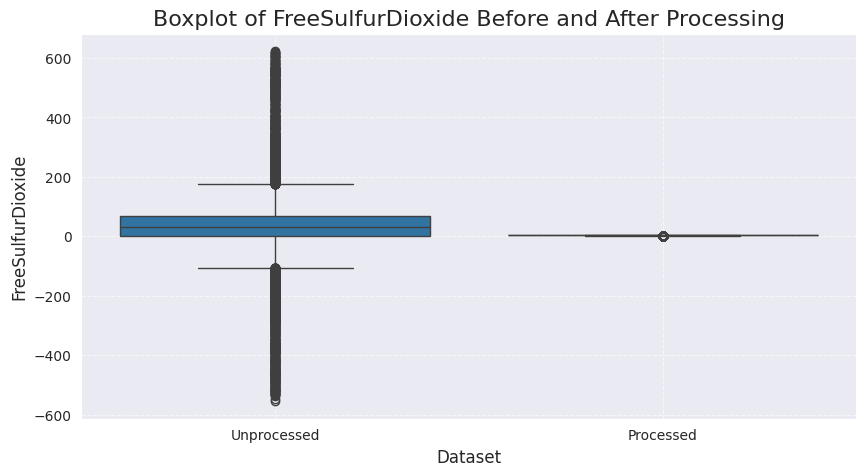

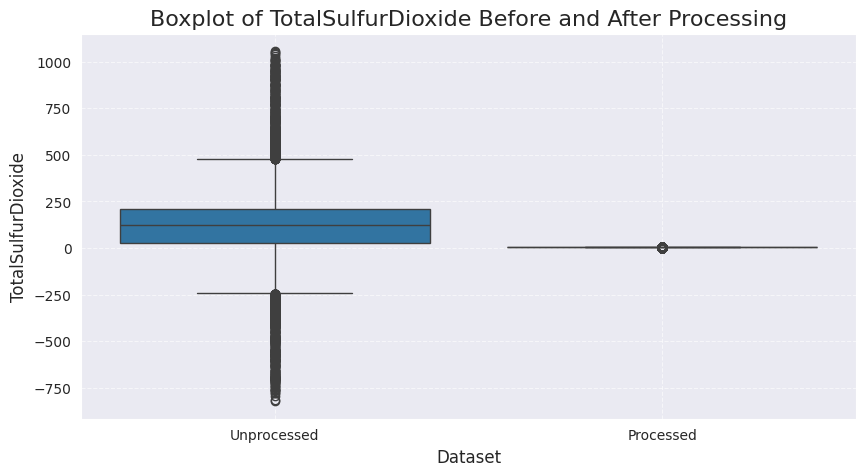

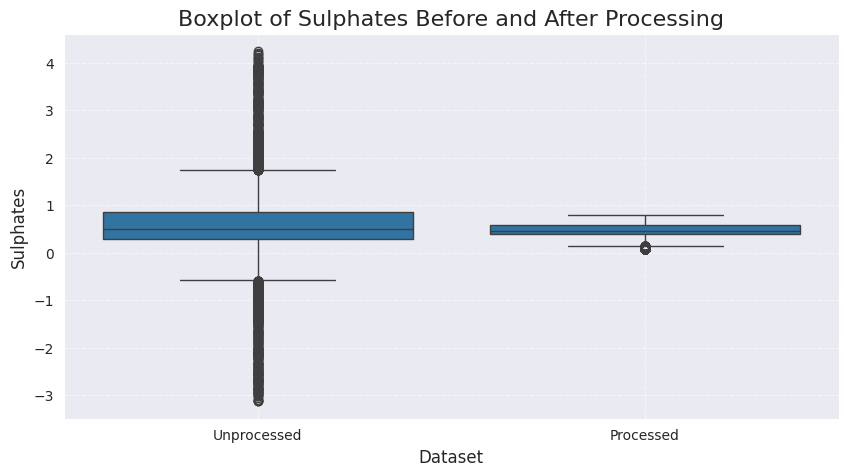

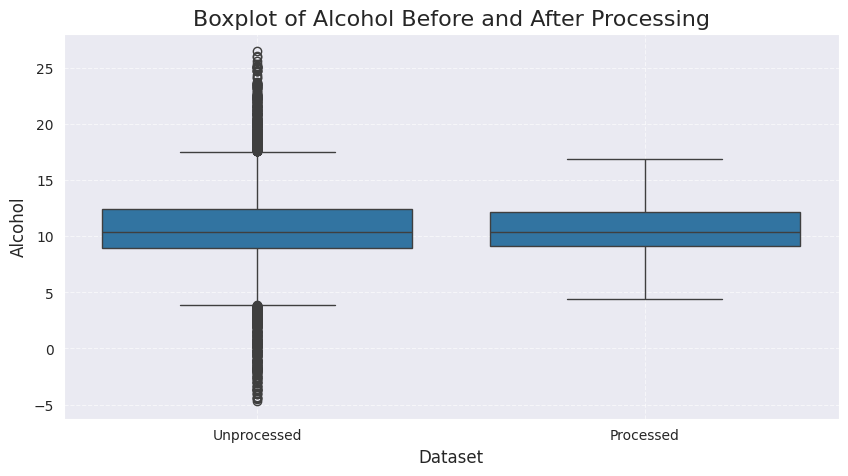

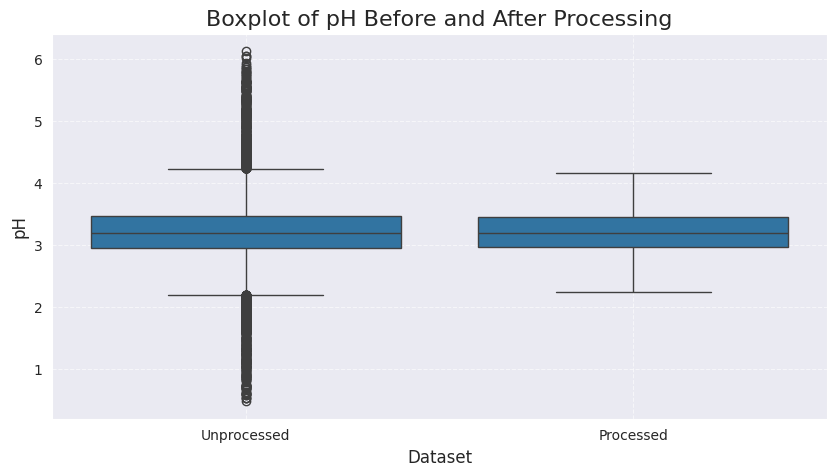

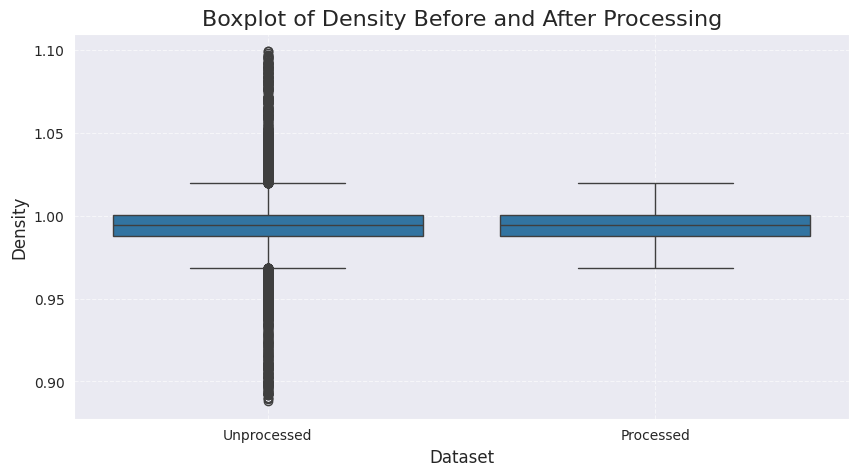

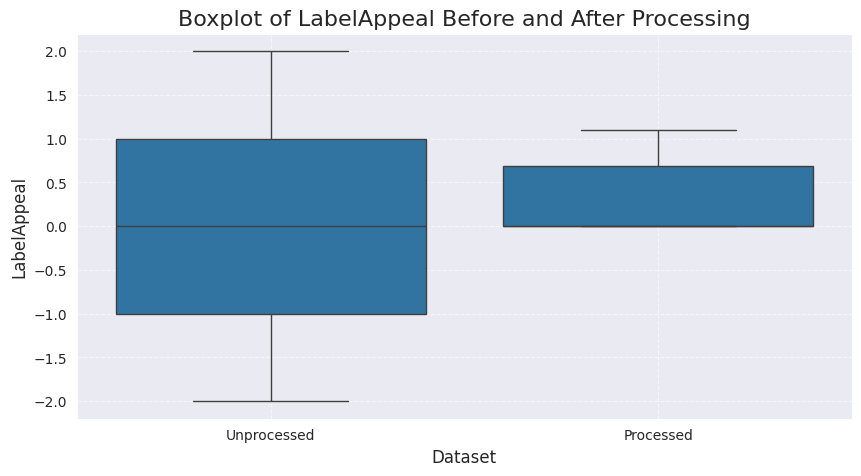

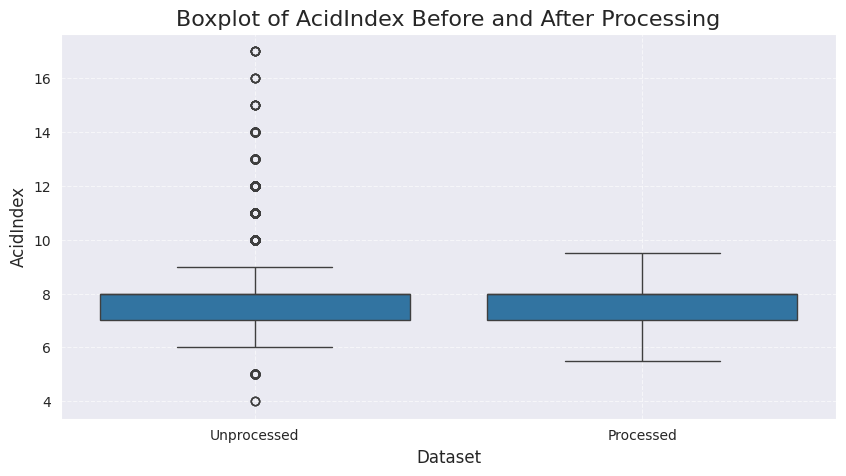

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Columns to plot
cols_to_plot = [
    'FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar',
    'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
    'Sulphates', 'Alcohol', 'pH', 'Density', 'LabelAppeal', 'AcidIndex'
]

# Create a copy and ensure columns are numeric to avoid TypeError
df_num = df.copy()
X_num = X.copy()

# Convert columns to a numerical type, coercing non-numeric values to NaN
for col in cols_to_plot:
    df_num[col] = pd.to_numeric(df_num[col], errors='coerce')
    X_num[col] = pd.to_numeric(X_num[col], errors='coerce')


for col in cols_to_plot:
    plt.figure(figsize=(10, 5))

    # Create a DataFrame for plotting, ensuring data is from the numerical copies
    plot_df = pd.DataFrame({
        'Unprocessed': df_num[col],
        'Processed': X_num[col]
    })

    # Melt the DataFrame to long format for seaborn
    plot_df_melted = plot_df.melt(var_name='Dataset', value_name=col)

    # Create the box plots
    sns.boxplot(x='Dataset', y=col, data=plot_df_melted)

    plt.title(f'Boxplot of {col} Before and After Processing', fontsize=16)
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

**Compairing the two box plots:**


*   Unprocessed data has a lot of outliers which is not seen in the processed data.
*   The whiskers for the processed data has become tighter and it looks cleaner.


###**4.5 Correlation Heatmap**

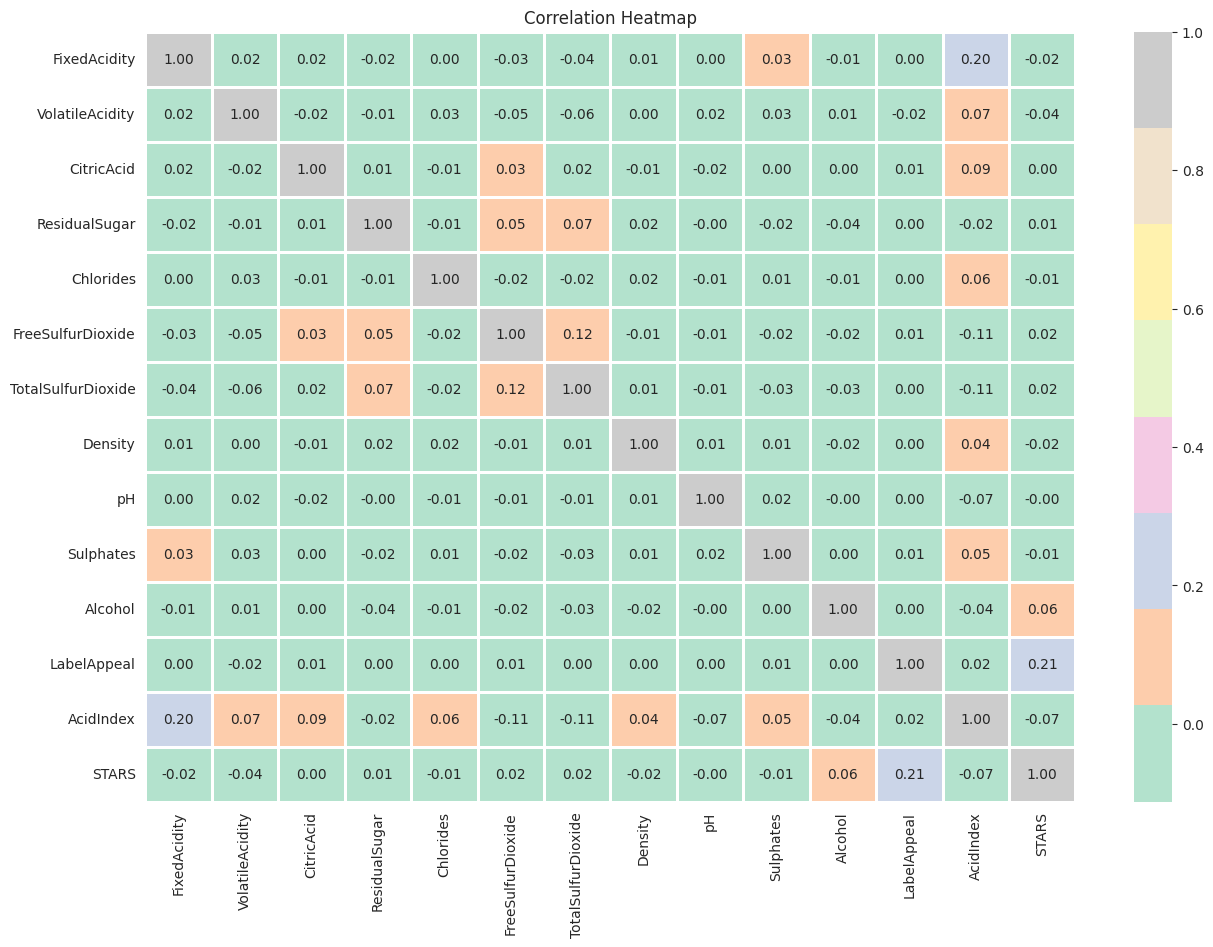

In [22]:
#Correlation Heatmap
plt.figure(figsize=(15, 10))

sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

# **5.Conclusion**

This assignment demonstrated the full process of preparing a wine dataset for machine learning, from initial exploration to final cleaning.  

*EDA Findings:*  
- Detected invalid negative values in chemical attributes, ~26% missing in STARS, and unrealistic Alcohol levels.  
- Most variables were symmetric, but AcidIndex showed severe right skew (skewness > 1.5).  
- Boxplots confirmed outliers, and correlations showed STARS and LabelAppeal were more predictive of sales than chemical composition.  

*Data Preparation:*  
- Negative values were set to NaN and imputed (median for numeric, mode for categorical).  
- AcidIndex was log-transformed, reducing skewness from ~1.65 to ~0.25.  
- Unrealistic alcohol values were adjusted, and missing STARS ratings imputed.  
- A new variable (AcidIndex_log) preserved the transformed version for modeling.  

*Post-Cleaning Review:*  
- Dataset now has no missing values, no invalid negatives, and reduced skewness.  
- Distributions are more balanced, making the data stable for ML.  

*Key Takeaway:*  
The dataset was transformed from incomplete and inconsistent to clean, valid, and machine-learning ready. Perceptual features (STARS, LabelAppeal) emerged as stronger predictors of sales than chemical measures, underscoring the importance of both expert ratings and marketing in wine performance.



#**6.References**
- GeeksforGeeks. (2021a, August 11). Steps for mastering exploratory data analysis (EDA steps). GeeksforGeeks. https://www.geeksforgeeks.org/data-analysis/steps-for-mastering-exploratory-data-analysis-eda-steps/  
- GeeksforGeeks. (2021b, July 26). Exploratory data analysis in Python. GeeksforGeeks. https://www.geeksforgeeks.org/data-analysis/exploratory-data-analysis-in-python/